# DataSense CIC-IIoT 2025 Deployment-Aware IDS Benchmark

This notebook is part of the implementation repository for the paper:

**Beyond Accuracy: A Deployment-Aware Multi-Dataset Evaluation of Machine Learning and Deep Learning Models for IoT/IIoT Intrusion Detection.**

## Dataset Used

This notebook uses the DataSense CIC-IIoT 2025 dataset for four-class IIoT intrusion detection.

The target classes are:

1. BENIGN
2. DDOS
3. DOS
4. MIRAI

The experiment evaluates the dataset under two feature settings:

1. Full-feature setting
2. Reduced-feature setting

The full-feature setting uses all valid numeric network features available in the experiment file. The reduced-feature setting uses a selected subset of features to evaluate deployment-aware feature reduction.

## Models Evaluated

The following models are evaluated:

1. Decision Tree
2. Random Forest
3. XGBoost
4. LightGBM
5. MLP/DNN
6. CNN-LSTM-Attention

## Evaluation Metrics

The evaluation includes accuracy, balanced accuracy, macro-F1, weighted-F1, false positives per 10,000 benign samples, training time, inference time, latency, throughput, and model size.

## Dataset Note

The raw dataset is not included in this repository because of size and dataset usage restrictions. Before running this notebook, download the corresponding dataset and update the dataset path in the configuration cell.

## Cell 1 — Configuration

Change only `DATASET_PATH` if the automatic CSV finder does not select the correct file.

If the dataset has a `Spoofing` class and you intentionally want to remove it, put it in `DROP_LABELS`. Otherwise leave `DROP_LABELS = []`.


In [13]:
# Put your cleaned 4-class CSV path here
DATASET_PATH = "/kaggle/input/datasets/frazyousaf022/datasense-cic-iiot-dataset-2025/DataSense CIC IIoT dataset 2025.csv"

DATASET_GLOB = "/kaggle/input/**/*.csv"
DATASET_NAME = "DataSense CIC IIoT 2025 - Common 4-Class Cleaned"
LABEL_COL = "label"

DROP_LABELS = []

RANDOM_SEED = 42
TEST_SIZE = 0.20

TOP_K_FEATURES = 35
CORR_THRESHOLD = 0.98
FEATURE_SELECTION_SAMPLE_ROWS = 200_000
CORRELATION_SAMPLE_ROWS = 100_000

DL_EPOCHS = 7
DL_BATCH_SIZE = 1024
DL_PATIENCE = 2

BENCHMARK_SAMPLE_SIZE = 20_000
BENCHMARK_BATCH_SIZE = 4096

MAX_ROWS = None

# Use a new output folder so you do not overwrite old results
WORK_DIR = Path("/kaggle/working/datasense_cic_iiot_2025")
RESULTS_DIR = WORK_DIR / "results"
ARTIFACTS_DIR = WORK_DIR / "artifacts"
MODELS_DIR = WORK_DIR / "models"
PAPER_DIR = WORK_DIR / "paper_outputs"

for d in [WORK_DIR, RESULTS_DIR, ARTIFACTS_DIR, MODELS_DIR, PAPER_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Work directory:", WORK_DIR)
print("Results directory:", RESULTS_DIR)
print("Artifacts directory:", ARTIFACTS_DIR)
print("Models directory:", MODELS_DIR)
print("Paper-output directory:", PAPER_DIR)

Work directory: /kaggle/working/datasense_cic_iiot_2025
Results directory: /kaggle/working/datasense_cic_iiot_2025/results
Artifacts directory: /kaggle/working/datasense_cic_iiot_2025/artifacts
Models directory: /kaggle/working/datasense_cic_iiot_2025/models
Paper-output directory: /kaggle/working/datasense_cic_iiot_2025/paper_outputs


## Cell 2 — Imports and hardware check

Tree models are run on CPU for stability. TensorFlow will use GPU automatically if Kaggle provides one.


In [14]:
# =========================
# IMPORTS AND ENVIRONMENT
# =========================

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import gc
import glob
import json
import time
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from IPython.display import display, FileLink

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone

warnings.filterwarnings("ignore")

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    print("XGBoost import failed:", repr(e))

try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except Exception as e:
    LIGHTGBM_AVAILABLE = False
    print("LightGBM import failed:", repr(e))

try:
    import tensorflow as tf
    from tensorflow.keras import layers, models, callbacks
    TENSORFLOW_AVAILABLE = True
except Exception as e:
    TENSORFLOW_AVAILABLE = False
    print("TensorFlow import failed:", repr(e))

np.random.seed(RANDOM_SEED)

print("XGBoost available:", XGBOOST_AVAILABLE)
print("LightGBM available:", LIGHTGBM_AVAILABLE)
print("TensorFlow available:", TENSORFLOW_AVAILABLE)

if TENSORFLOW_AVAILABLE:
    gpus = tf.config.list_physical_devices("GPU")
    print("TensorFlow GPUs:", gpus if gpus else "No GPU detected; DL will run on CPU.")


XGBoost available: True
LightGBM available: True
TensorFlow available: True
TensorFlow GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 3 — Locate and load the dataset

If multiple CSV files exist, this cell prints the candidates and prefers files whose path contains `datasense`, `iiot`, or `cic`.


In [15]:
# =========================
# LOCATE AND LOAD DATASET
# =========================

def resolve_dataset_path():
    if DATASET_PATH:
        p = Path(DATASET_PATH)
        if not p.exists():
            raise FileNotFoundError(f"DATASET_PATH does not exist: {p}")
        return str(p)

    candidates = sorted(glob.glob(DATASET_GLOB, recursive=True))
    if not candidates:
        raise FileNotFoundError("No CSV files found under /kaggle/input. Upload/add the dataset first.")

    print("CSV candidates found:")
    for i, c in enumerate(candidates[:30], start=1):
        print(f"{i:02d}. {c}")
    if len(candidates) > 30:
        print(f"... plus {len(candidates) - 30} more")

    preferred_terms = ["datasense", "iiot", "cic"]
    preferred = [
        c for c in candidates
        if any(term in c.lower() for term in preferred_terms)
    ]

    if len(preferred) == 1:
        return preferred[0]

    if len(preferred) > 1:
        # Prefer the largest likely dataset file.
        preferred = sorted(preferred, key=lambda p: os.path.getsize(p), reverse=True)
        print("\nMultiple preferred CSVs found. Selected the largest preferred file:")
        print(preferred[0])
        return preferred[0]

    # Fallback: largest CSV.
    candidates = sorted(candidates, key=lambda p: os.path.getsize(p), reverse=True)
    print("\nNo preferred filename found. Selected the largest CSV:")
    print(candidates[0])
    return candidates[0]

dataset_path = resolve_dataset_path()
print("\nUsing dataset:", dataset_path)

read_kwargs = {"low_memory": False}
if MAX_ROWS is not None:
    read_kwargs["nrows"] = MAX_ROWS

df = pd.read_csv(dataset_path, **read_kwargs)

print("Dataset name:", DATASET_NAME)
print("Shape:", df.shape)
print("Columns:", len(df.columns))
display(df.head())

if LABEL_COL not in df.columns:
    raise ValueError(f"Expected label column '{LABEL_COL}' not found. Available columns: {list(df.columns)[:20]} ...")

print("\nRaw label distribution:")
display(df[LABEL_COL].value_counts(dropna=False).to_frame("count"))



Using dataset: /kaggle/input/datasets/frazyousaf022/datasense-cic-iiot-dataset-2025/DataSense CIC IIoT dataset 2025.csv
Dataset name: DataSense CIC IIoT 2025 - Common 4-Class Cleaned
Shape: (281182, 70)
Columns: 70


,log_data-ranges_avg,log_data-ranges_max,log_data-ranges_min,log_data-ranges_std_deviation,log_data-types_count,log_interval-messages,log_messages_count,network_fragmentation-score,network_fragmented-packets,network_header-length_avg,...,network_time-delta_std_deviation,network_ttl_avg,network_ttl_max,network_ttl_min,network_ttl_std_deviation,network_window-size_avg,network_window-size_max,network_window-size_min,network_window-size_std_deviation,label
0,0.0,0.0,0.0,0.0,0,0.0,0,0.0,0,20.0,...,0.000042,64.0,64,64,0.0,17587.53231,64240,0,28377.70170,DDOS
1,0.0,0.0,0.0,0.0,0,0.0,0,0.0,0,20.0,...,0.000041,64.0,64,64,0.0,17259.30789,64240,0,28201.47752,DDOS
2,0.0,0.0,0.0,0.0,0,0.0,0,0.0,0,20.0,...,0.000041,64.0,64,64,0.0,17185.87831,64240,0,28161.43853,DDOS
3,0.0,0.0,0.0,0.0,0,0.0,0,0.0,0,20.0,...,0.000041,64.0,64,64,0.0,16750.71847,64240,0,27918.42249,DDOS
4,0.0,0.0,0.0,0.0,0,0.0,0,0.0,0,20.0,...,0.000041,64.0,64,64,0.0,16673.44607,64240,0,27874.48639,DDOS



Raw label distribution:


,count
label,
BENIGN,204060
DOS,32188
DDOS,31580
MIRAI,13354


## Cell 4 — Label cleaning and optional class removal

This cell standardizes whitespace/case problems in the label column. It does **not** merge attack classes.


In [16]:
# =========================
# LABEL CLEANING + 4-CLASS VALIDATION
# =========================

df = df.copy()

# Clean column names
df.columns = [str(c).strip() for c in df.columns]

if LABEL_COL not in df.columns:
    raise ValueError(f"Label column '{LABEL_COL}' not found after stripping column names.")

# Clean labels
df[LABEL_COL] = df[LABEL_COL].astype(str).str.upper().str.strip()

# Normalize benign spellings
benign_spellings = {"BENIGN", "NORMAL", "NORMAL_TRAFFIC", "NORMAL TRAFFIC"}
df[LABEL_COL] = df[LABEL_COL].apply(
    lambda x: "BENIGN" if x.strip().upper() in benign_spellings else x.strip().upper()
)

# Since this CSV is already edited, this is only a safety check.
EXPECTED_LABELS = ["BENIGN", "DDOS", "DOS", "MIRAI"]

unexpected_labels = sorted(set(df[LABEL_COL].unique()) - set(EXPECTED_LABELS))
if unexpected_labels:
    raise ValueError(
        f"Unexpected labels found: {unexpected_labels}. "
        "Your cleaned dataset should contain only BENIGN, DDOS, DOS, MIRAI."
    )

# Remove missing/empty labels
before = len(df)
df = df[df[LABEL_COL].notna()]
df = df[df[LABEL_COL].astype(str).str.len() > 0].copy()
print(f"Removed {before - len(df):,} rows with missing/empty labels.")

print("Experiment mode: common_4class_cleaned_csv")
print("Cleaned shape:", df.shape)
print("\nCleaned label distribution:")

label_counts = df[LABEL_COL].value_counts().to_frame("count")
label_counts["percent"] = 100 * label_counts["count"] / len(df)
display(label_counts)

class_count = df[LABEL_COL].nunique()
if class_count != 4:
    raise ValueError(f"Expected 4 classes, but found {class_count}: {sorted(df[LABEL_COL].unique())}")

min_count = df[LABEL_COL].value_counts().min()
if min_count < 2:
    raise ValueError("At least one class has fewer than 2 rows. Classification cannot work properly.")

Removed 0 rows with missing/empty labels.
Experiment mode: common_4class_cleaned_csv
Cleaned shape: (281182, 70)

Cleaned label distribution:


,count,percent
label,,
BENIGN,204060,72.572213
DOS,32188,11.447390
DDOS,31580,11.231160
MIRAI,13354,4.749237


## Cell 5 — Feature preparation for DataSense CIC IIoT 2025

This is the most important change from the previous notebook.

The old dataset had a different feature schema. This notebook does **not** expect old feature names. It dynamically keeps numeric columns and drops:
- device identifiers
- timestamps
- raw string/list columns such as IP/MAC/port/protocol lists
- constant columns
- columns with too many missing values

The count/statistical columns are kept.


In [17]:
# =========================
# FEATURE PREPARATION
# =========================

# Columns that are identifiers, timestamps, or raw list/text fields.
# These are excluded because they are not stable deployable numeric features and can cause leakage/high cardinality.
FORCED_DROP_COLUMNS = {
    "device_name",
    "device_mac",
    "timestamp",
    "timestamp_start",
    "timestamp_end",
}

# Extra safety: drop raw list columns by name pattern.
RAW_LIST_PATTERNS = [
    "_all", "_dst", "_src",
]
RAW_LIST_EXACT_OR_PREFIX = [
    "network_ips_",
    "network_macs_",
    "network_ports_",
    "network_protocols_",
    "log_data-types",
]

def is_raw_text_list_column(col):
    c = str(col)
    if c.endswith("_count"):
        return False
    if c in FORCED_DROP_COLUMNS:
        return True
    if any(c.startswith(prefix) for prefix in RAW_LIST_EXACT_OR_PREFIX):
        # Keep *_count columns only. Drop the raw list columns.
        return not c.endswith("_count")
    return False

feature_candidates = [c for c in df.columns if c != LABEL_COL]

dropped_columns = []
numeric_data = {}

for col in feature_candidates:
    if col in FORCED_DROP_COLUMNS or is_raw_text_list_column(col):
        dropped_columns.append((col, "forced_identifier_timestamp_or_raw_list"))
        continue

    # Convert numeric-looking object columns safely.
    converted = pd.to_numeric(df[col], errors="coerce")
    valid_ratio = converted.notna().mean()

    # Keep columns that are already numeric or mostly numeric after conversion.
    if pd.api.types.is_numeric_dtype(df[col]) or valid_ratio >= 0.90:
        numeric_data[col] = converted.astype("float32")
    else:
        dropped_columns.append((col, f"non_numeric_or_low_numeric_ratio={valid_ratio:.3f}"))

X_df = pd.DataFrame(numeric_data, index=df.index)

# Replace infinite values
X_df = X_df.replace([np.inf, -np.inf], np.nan)

# Drop columns with excessive missingness
missing_ratio = X_df.isna().mean()
too_missing = missing_ratio[missing_ratio > 0.50].index.tolist()
if too_missing:
    X_df = X_df.drop(columns=too_missing)
    for col in too_missing:
        dropped_columns.append((col, "missing_ratio_gt_0.50"))

# Drop constant columns
constant_cols = [c for c in X_df.columns if X_df[c].nunique(dropna=True) <= 1]
if constant_cols:
    X_df = X_df.drop(columns=constant_cols)
    for col in constant_cols:
        dropped_columns.append((col, "constant_or_single_unique_value"))

# Fill remaining missing values with median
medians = X_df.median(numeric_only=True)
X_df = X_df.fillna(medians).astype("float32")

if X_df.shape[1] == 0:
    raise ValueError("No usable numeric features remain. Check the dataset schema and feature-cleaning rules.")

y_labels = df[LABEL_COL].astype(str).values

feature_cols = list(X_df.columns)

print("Rows:", X_df.shape[0])
print("Usable numeric features:", X_df.shape[1])
print("Dropped columns:", len(dropped_columns))

feature_report = pd.DataFrame({
    "feature": feature_cols,
    "dtype": [str(X_df[c].dtype) for c in feature_cols],
    "missing_after_fill": [int(X_df[c].isna().sum()) for c in feature_cols],
    "n_unique": [int(X_df[c].nunique(dropna=True)) for c in feature_cols],
})
display(feature_report)

dropped_report = pd.DataFrame(dropped_columns, columns=["column", "reason"])
display(dropped_report.head(50))

feature_report.to_csv(ARTIFACTS_DIR / "used_numeric_features.csv", index=False)
dropped_report.to_csv(ARTIFACTS_DIR / "dropped_columns_report.csv", index=False)

print("Saved feature reports to:", ARTIFACTS_DIR)


Rows: 281182
Usable numeric features: 69
Dropped columns: 0


,feature,dtype,missing_after_fill,n_unique
0,log_data-ranges_avg,float32,0,2999
1,log_data-ranges_max,float32,0,511
2,log_data-ranges_min,float32,0,437
3,log_data-ranges_std_deviation,float32,0,5313
4,log_data-types_count,float32,0,3
...,...,...,...,...
64,network_ttl_std_deviation,float32,0,41318
65,network_window-size_avg,float32,0,48860
66,network_window-size_max,float32,0,359
67,network_window-size_min,float32,0,574


,column,reason


Saved feature reports to: /kaggle/working/datasense_cic_iiot_2025/artifacts


## Cell 6 — Encode labels, split data, and scale for deep learning

The same train/test split is used for all models.


In [18]:
# =========================
# LABEL ENCODING, TRAIN/TEST SPLIT, SCALING
# =========================

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_labels)
class_names = label_encoder.classes_.tolist()
n_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", n_classes)

X = X_df.values.astype("float32")

stratify = y if pd.Series(y).value_counts().min() >= 2 else None
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=stratify,
)

scaler_full = StandardScaler()
X_train_scaled = scaler_full.fit_transform(X_train).astype("float32")
X_test_scaled = scaler_full.transform(X_test).astype("float32")

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {int(cls): float(w) for cls, w in zip(np.unique(y_train), class_weights_array)}

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Class weights:", class_weight_dict)

# Save reusable artifacts
joblib.dump(label_encoder, ARTIFACTS_DIR / "label_encoder.joblib")
joblib.dump(scaler_full, ARTIFACTS_DIR / "scaler_full.joblib")

with open(ARTIFACTS_DIR / "class_names.json", "w") as f:
    json.dump(class_names, f, indent=2)

with open(ARTIFACTS_DIR / "full_feature_names.json", "w") as f:
    json.dump(feature_cols, f, indent=2)

print("Artifacts saved.")


Classes: ['BENIGN', 'DDOS', 'DOS', 'MIRAI']
Number of classes: 4
Train shape: (224945, 69)
Test shape: (56237, 69)
Class weights: {0: 0.3444835465059296, 1: 2.225944031032299, 2: 2.1839320388349512, 3: 5.264087803051577}
Artifacts saved.


## Cell 7 — Build reduced feature set

Reduced features are selected using Random-Forest feature importance, then highly correlated features are removed. This avoids using a feature list from an incompatible dataset.


In [19]:
# =========================
# REDUCED FEATURE SELECTION
# =========================

def make_sample_indices(n_rows, max_rows, seed):
    rng = np.random.default_rng(seed)
    if n_rows <= max_rows:
        return np.arange(n_rows)
    return rng.choice(n_rows, size=max_rows, replace=False)

fs_idx = make_sample_indices(len(X_train), FEATURE_SELECTION_SAMPLE_ROWS, RANDOM_SEED)

selector_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=None,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    class_weight="balanced_subsample",
)

print("Fitting feature-selection Random Forest on rows:", len(fs_idx))
selector_start = time.perf_counter()
selector_model.fit(X_train[fs_idx], y_train[fs_idx])
selector_time = time.perf_counter() - selector_start
print(f"Feature selector training time: {selector_time:.2f} sec")

importances = selector_model.feature_importances_
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importances
}).sort_values("importance", ascending=False).reset_index(drop=True)

display(importance_df.head(50))
importance_df.to_csv(ARTIFACTS_DIR / "feature_importance_random_forest.csv", index=False)

# Correlation-aware selection
corr_idx = make_sample_indices(len(X_train), CORRELATION_SAMPLE_ROWS, RANDOM_SEED + 1)
corr_df = pd.DataFrame(X_train[corr_idx], columns=feature_cols)

selected_features = []
selected_indices = []

for _, row in importance_df.iterrows():
    feature = row["feature"]
    feature_idx = feature_cols.index(feature)

    if len(selected_features) == 0:
        selected_features.append(feature)
        selected_indices.append(feature_idx)
    else:
        candidate = corr_df[feature]
        keep = True
        for already in selected_features:
            corr_value = candidate.corr(corr_df[already])
            if pd.notna(corr_value) and abs(corr_value) >= CORR_THRESHOLD:
                keep = False
                break
        if keep:
            selected_features.append(feature)
            selected_indices.append(feature_idx)

    if len(selected_features) >= min(TOP_K_FEATURES, len(feature_cols)):
        break

# If correlation filtering is too aggressive, fill remaining by importance order.
if len(selected_features) < min(TOP_K_FEATURES, len(feature_cols)):
    for feature in importance_df["feature"]:
        if feature not in selected_features:
            selected_features.append(feature)
            selected_indices.append(feature_cols.index(feature))
        if len(selected_features) >= min(TOP_K_FEATURES, len(feature_cols)):
            break

X_train_reduced = X_train[:, selected_indices].astype("float32")
X_test_reduced = X_test[:, selected_indices].astype("float32")

scaler_reduced = StandardScaler()
X_train_reduced_scaled = scaler_reduced.fit_transform(X_train_reduced).astype("float32")
X_test_reduced_scaled = scaler_reduced.transform(X_test_reduced).astype("float32")

joblib.dump(scaler_reduced, ARTIFACTS_DIR / "scaler_reduced.joblib")

with open(ARTIFACTS_DIR / "reduced_feature_names.json", "w") as f:
    json.dump(selected_features, f, indent=2)

print("Full feature count:", len(feature_cols))
print("Reduced feature count:", len(selected_features))
print("Reduced features:")
for i, f_name in enumerate(selected_features, start=1):
    print(f"{i:02d}. {f_name}")


Fitting feature-selection Random Forest on rows: 200000
Feature selector training time: 31.43 sec


,feature,importance
0,network_time-delta_avg,0.088861
1,network_packets_dst_count,0.079667
2,network_packets_all_count,0.067519
3,network_interval-packets,0.062856
4,network_time-delta_min,0.056374
5,network_macs_dst_count,0.051465
6,network_macs_all_count,0.050118
7,network_ips_all_count,0.047978
8,network_time-delta_std_deviation,0.046911
9,network_packet-size_min,0.045253


Full feature count: 69
Reduced feature count: 35
Reduced features:
01. network_time-delta_avg
02. network_packets_dst_count
03. network_interval-packets
04. network_time-delta_min
05. network_macs_dst_count
06. network_ips_all_count
07. network_time-delta_std_deviation
08. network_packet-size_min
09. network_time-delta_max
10. network_ports_dst_count
11. network_ports_all_count
12. network_ports_src_count
13. network_window-size_std_deviation
14. network_ttl_avg
15. network_ip-length_avg
16. network_window-size_max
17. network_mss_min
18. network_tcp-flags_std_deviation
19. network_window-size_avg
20. network_packet-size_avg
21. network_payload-length_std_deviation
22. network_window-size_min
23. network_ip-length_max
24. network_ttl_std_deviation
25. network_protocols_dst_count
26. network_packets_src_count
27. network_ip-flags_avg
28. network_tcp-flags-syn_count
29. network_payload-length_avg
30. network_ip-length_std_deviation
31. network_packet-size_std_deviation
32. network_ttl_mi

## Cell 8 — Evaluation and result-saving utilities

In [20]:
# =========================
# EVALUATION UTILITIES
# =========================

all_results = []

def get_benign_class_index(class_names):
    for i, name in enumerate(class_names):
        if str(name).strip().lower() in {"benign", "normal", "normal_traffic", "normal traffic"}:
            return i
    return None

BENIGN_CLASS_INDEX = get_benign_class_index(class_names)
print("Benign class index:", BENIGN_CLASS_INDEX)

def compute_all_metrics(y_true, y_pred, class_names):
    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
    }

    if BENIGN_CLASS_INDEX is not None:
        benign_mask = (y_true == BENIGN_CLASS_INDEX)
        benign_total = int(benign_mask.sum())
        if benign_total > 0:
            false_positive_count = int(np.sum(benign_mask & (y_pred != BENIGN_CLASS_INDEX)))
            metrics["fp_per_10000_benign"] = float(false_positive_count / benign_total * 10000.0)
            metrics["benign_test_samples"] = benign_total
            metrics["benign_false_positives"] = false_positive_count
        else:
            metrics["fp_per_10000_benign"] = np.nan
            metrics["benign_test_samples"] = 0
            metrics["benign_false_positives"] = 0
    else:
        metrics["fp_per_10000_benign"] = np.nan
        metrics["benign_test_samples"] = 0
        metrics["benign_false_positives"] = 0

    return metrics

def benchmark_predict(predict_fn, X_eval, sample_size=BENCHMARK_SAMPLE_SIZE):
    n = min(len(X_eval), sample_size)
    X_sample = X_eval[:n]

    start = time.perf_counter()
    _ = predict_fn(X_sample)
    total_time = time.perf_counter() - start

    per_sample_ms = (total_time / max(n, 1)) * 1000.0
    throughput = n / total_time if total_time > 0 else np.nan

    return {
        "benchmark_samples": int(n),
        "total_inference_time_sec": float(total_time),
        "mean_latency_ms_per_sample": float(per_sample_ms),
        "throughput_samples_per_sec": float(throughput),
    }

def save_classification_outputs(model_name, feature_set, y_true, y_pred):
    safe_name = f"{model_name}_{feature_set}".replace("/", "_").replace(" ", "_")

    report_text = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0,
    )
    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0,
        output_dict=True,
    )

    with open(RESULTS_DIR / f"classification_report_{safe_name}.txt", "w") as f:
        f.write(report_text)

    with open(RESULTS_DIR / f"classification_report_{safe_name}.json", "w") as f:
        json.dump(report_dict, f, indent=2)

    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
    cm_df.to_csv(RESULTS_DIR / f"confusion_matrix_{safe_name}.csv")

    print(f"\n=== {model_name} | {feature_set} ===")
    print(report_text)

def model_file_size_mb(path):
    path = Path(path)
    if path.is_file():
        return path.stat().st_size / (1024 * 1024)
    if path.is_dir():
        return sum(p.stat().st_size for p in path.rglob("*") if p.is_file()) / (1024 * 1024)
    return np.nan

def add_result(model_name, feature_set, features_used, y_true, y_pred, training_time_sec, inference_metrics, model_path):
    metrics = compute_all_metrics(y_true, y_pred, class_names)

    row = {
        "dataset": DATASET_NAME,
        "model": model_name,
        "feature_set": feature_set,
        "n_features": len(features_used),
        "features_used": json.dumps(list(features_used)),
        **metrics,
        "training_time_sec": float(training_time_sec),
        **inference_metrics,
        "model_size_mb": float(model_file_size_mb(model_path)),
        "model_path": str(model_path),
    }

    all_results.append(row)
    save_classification_outputs(model_name, feature_set, y_true, y_pred)
    pd.DataFrame(all_results).to_csv(RESULTS_DIR / "running_model_comparison.csv", index=False)

def save_final_results():
    final_df = pd.DataFrame(all_results)
    final_path = RESULTS_DIR / "final_model_comparison.csv"
    final_df.to_csv(final_path, index=False)
    print("Saved:", final_path)
    return final_df


Benign class index: 0


## Cell 9 — Classical ML model runners

In [21]:
# =========================
# CLASSICAL MODEL RUNNERS
# =========================

def fit_predict_sklearn(model_name, model, Xtr, Xte, ytr, yte, features_used, feature_set, sample_weight=None):
    model_path = MODELS_DIR / f"{model_name}_{feature_set}.joblib"

    start = time.perf_counter()
    if sample_weight is not None:
        model.fit(Xtr, ytr, sample_weight=sample_weight)
    else:
        model.fit(Xtr, ytr)
    training_time = time.perf_counter() - start

    y_pred = model.predict(Xte)

    joblib.dump(model, model_path)

    inference_metrics = benchmark_predict(lambda x: model.predict(x), Xte)

    add_result(
        model_name=model_name,
        feature_set=feature_set,
        features_used=features_used,
        y_true=yte,
        y_pred=y_pred,
        training_time_sec=training_time,
        inference_metrics=inference_metrics,
        model_path=model_path,
    )

    gc.collect()
    return model

def make_sample_weight(y_values):
    return np.array([class_weight_dict[int(cls)] for cls in y_values], dtype="float32")

sample_weight_train = make_sample_weight(y_train)

def run_decision_tree(Xtr, Xte, features_used, feature_set):
    model = DecisionTreeClassifier(
        random_state=RANDOM_SEED,
        class_weight=class_weight_dict,
    )
    return fit_predict_sklearn(
        "DecisionTree", model, Xtr, Xte, y_train, y_test,
        features_used, feature_set
    )

def run_random_forest(Xtr, Xte, features_used, feature_set):
    model = RandomForestClassifier(
        n_estimators=250,
        max_depth=None,
        min_samples_leaf=1,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        class_weight="balanced_subsample",
    )
    return fit_predict_sklearn(
        "RandomForest", model, Xtr, Xte, y_train, y_test,
        features_used, feature_set
    )

def run_xgboost(Xtr, Xte, features_used, feature_set):
    if not XGBOOST_AVAILABLE:
        print("Skipping XGBoost because it is not available.")
        return None

    if n_classes == 2:
        objective = "binary:logistic"
        eval_metric = "logloss"
        extra = {}
    else:
        objective = "multi:softprob"
        eval_metric = "mlogloss"
        extra = {"num_class": n_classes}

    model = XGBClassifier(
        objective=objective,
        eval_metric=eval_metric,
        n_estimators=350,
        max_depth=6,
        learning_rate=0.08,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=1,
        reg_lambda=1.0,
        tree_method="hist",       # CPU-stable. Change only if you know your GPU XGBoost version supports GPU.
        random_state=RANDOM_SEED,
        n_jobs=-1,
        **extra,
    )

    return fit_predict_sklearn(
        "XGBoost", model, Xtr, Xte, y_train, y_test,
        features_used, feature_set,
        sample_weight=sample_weight_train
    )

def run_lightgbm(Xtr, Xte, features_used, feature_set):
    if not LIGHTGBM_AVAILABLE:
        print("Skipping LightGBM because it is not available.")
        return None

    model = LGBMClassifier(
        objective="multiclass" if n_classes > 2 else "binary",
        num_class=n_classes if n_classes > 2 else None,
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        max_depth=-1,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        class_weight="balanced",
        verbosity=-1,
    )

    return fit_predict_sklearn(
        "LightGBM", model, Xtr, Xte, y_train, y_test,
        features_used, feature_set
    )


## Cell 10 — Run Decision Tree, Random Forest, XGBoost, and LightGBM

This runs each classical model on both full and reduced features.


In [22]:
# =========================
# RUN CLASSICAL ML MODELS
# =========================

classical_runs = [
    ("Full", X_train, X_test, feature_cols),
    ("Reduced", X_train_reduced, X_test_reduced, selected_features),
]

for feature_set, Xtr, Xte, used_features in classical_runs:
    print("\n" + "=" * 100)
    print(f"Running classical models on {feature_set} feature set ({len(used_features)} features)")
    print("=" * 100)

    run_decision_tree(Xtr, Xte, used_features, feature_set)
    run_random_forest(Xtr, Xte, used_features, feature_set)
    run_xgboost(Xtr, Xte, used_features, feature_set)
    run_lightgbm(Xtr, Xte, used_features, feature_set)

final_df_partial = save_final_results()
display(final_df_partial.sort_values(["macro_f1", "balanced_accuracy"], ascending=False))



Running classical models on Full feature set (69 features)

=== DecisionTree | Full ===
              precision    recall  f1-score   support

      BENIGN       0.98      1.00      0.99     40812
        DDOS       0.97      0.91      0.94      6316
         DOS       0.98      0.95      0.97      6438
       MIRAI       0.98      0.94      0.96      2671

    accuracy                           0.98     56237
   macro avg       0.98      0.95      0.96     56237
weighted avg       0.98      0.98      0.98     56237


=== RandomForest | Full ===
              precision    recall  f1-score   support

      BENIGN       0.98      1.00      0.99     40812
        DDOS       0.99      0.92      0.95      6316
         DOS       0.98      0.96      0.97      6438
       MIRAI       0.98      0.95      0.97      2671

    accuracy                           0.98     56237
   macro avg       0.98      0.96      0.97     56237
weighted avg       0.98      0.98      0.98     56237


=== XGBoost

,dataset,model,feature_set,n_features,features_used,accuracy,balanced_accuracy,macro_f1,weighted_f1,fp_per_10000_benign,benign_test_samples,benign_false_positives,training_time_sec,benchmark_samples,total_inference_time_sec,mean_latency_ms_per_sample,throughput_samples_per_sec,model_size_mb,model_path
1,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,RandomForest,Full,69,"[""log_data-ranges_avg"", ""log_data-ranges_max"",...",0.981969,0.955628,0.969639,0.981770,21.317260,40812,87,58.957210,20000,0.212185,0.010609,9.425748e+04,122.111321,/kaggle/working/datasense_cic_iiot_2025/models...
5,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,RandomForest,Reduced,35,"[""network_time-delta_avg"", ""network_packets_ds...",0.981756,0.955075,0.969347,0.981551,19.847104,40812,81,50.548202,20000,0.217704,0.010885,9.186778e+04,122.476800,/kaggle/working/datasense_cic_iiot_2025/models...
3,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,LightGBM,Full,69,"[""log_data-ranges_avg"", ""log_data-ranges_max"",...",0.980636,0.958152,0.966492,0.980494,53.660688,40812,219,54.036015,20000,1.378158,0.068908,1.451213e+04,13.430775,/kaggle/working/datasense_cic_iiot_2025/models...
2,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,XGBoost,Full,69,"[""log_data-ranges_avg"", ""log_data-ranges_max"",...",0.980404,0.955600,0.965795,0.980219,40.674311,40812,166,32.608873,20000,0.275723,0.013786,7.253652e+04,4.154643,/kaggle/working/datasense_cic_iiot_2025/models...
7,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,LightGBM,Reduced,35,"[""network_time-delta_avg"", ""network_packets_ds...",0.980191,0.956552,0.965378,0.980037,51.455454,40812,210,38.502257,20000,1.319964,0.065998,1.515193e+04,13.338627,/kaggle/working/datasense_cic_iiot_2025/models...
6,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,XGBoost,Reduced,35,"[""network_time-delta_avg"", ""network_packets_ds...",0.979746,0.954451,0.964577,0.979550,41.654415,40812,170,22.364389,20000,0.277418,0.013871,7.209340e+04,4.251814,/kaggle/working/datasense_cic_iiot_2025/models...
0,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,DecisionTree,Full,69,"[""log_data-ranges_avg"", ""log_data-ranges_max"",...",0.979729,0.951962,0.964295,0.979515,35.528766,40812,145,7.796462,20000,0.003770,0.000189,5.304552e+06,0.445992,/kaggle/working/datasense_cic_iiot_2025/models...
4,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,DecisionTree,Reduced,35,"[""network_time-delta_avg"", ""network_packets_ds...",0.979480,0.950917,0.963789,0.979248,30.628247,40812,125,5.514912,20000,0.003240,0.000162,6.172649e+06,0.459542,/kaggle/working/datasense_cic_iiot_2025/models...


## Cell 11 — Deep-learning model builders

MLP/DNN uses scaled tabular features. CNN-LSTM-Attention treats the tabular feature vector as a short sequence.


In [23]:
# =========================
# DEEP LEARNING MODEL BUILDERS
# =========================

if TENSORFLOW_AVAILABLE:
    tf.keras.utils.set_random_seed(RANDOM_SEED)

def build_mlp_dnn(input_dim, n_classes):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.30),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.25),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.20),
        layers.Dense(n_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

def build_cnn_lstm_attention(n_features, n_classes):
    inp = layers.Input(shape=(n_features, 1))

    x = layers.Conv1D(filters=32, kernel_size=3, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(filters=64, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    x = layers.Bidirectional(layers.LSTM(32, return_sequences=True))(x)

    attn = layers.MultiHeadAttention(num_heads=2, key_dim=16)(x, x)
    x = layers.Add()([x, attn])
    x = layers.LayerNormalization()(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.30)(x)

    out = layers.Dense(n_classes, activation="softmax")(x)

    model = models.Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

def fit_predict_keras(model_name, build_fn, Xtr_scaled, Xte_scaled, ytr, yte, features_used, feature_set, reshape_for_sequence=False):
    if not TENSORFLOW_AVAILABLE:
        print(f"Skipping {model_name} because TensorFlow is not available.")
        return None

    if reshape_for_sequence:
        Xtr_model = Xtr_scaled.reshape((Xtr_scaled.shape[0], Xtr_scaled.shape[1], 1))
        Xte_model = Xte_scaled.reshape((Xte_scaled.shape[0], Xte_scaled.shape[1], 1))
        model = build_fn(Xtr_scaled.shape[1], n_classes)
    else:
        Xtr_model = Xtr_scaled
        Xte_model = Xte_scaled
        model = build_fn(Xtr_scaled.shape[1], n_classes)

    early_stop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=DL_PATIENCE,
        restore_best_weights=True,
    )

    model_path = MODELS_DIR / f"{model_name}_{feature_set}.keras"

    start = time.perf_counter()
    history = model.fit(
        Xtr_model,
        ytr,
        validation_split=0.15,
        epochs=DL_EPOCHS,
        batch_size=DL_BATCH_SIZE,
        callbacks=[early_stop],
        class_weight=class_weight_dict,
        verbose=1,
    )
    training_time = time.perf_counter() - start

    pred_proba = model.predict(Xte_model, batch_size=DL_BATCH_SIZE, verbose=0)
    y_pred = np.argmax(pred_proba, axis=1)

    model.save(model_path)

    def keras_predict(x):
        if reshape_for_sequence:
            x = x.reshape((x.shape[0], x.shape[1], 1))
        return np.argmax(model.predict(x, batch_size=DL_BATCH_SIZE, verbose=0), axis=1)

    inference_metrics = benchmark_predict(keras_predict, Xte_scaled)

    add_result(
        model_name=model_name,
        feature_set=feature_set,
        features_used=features_used,
        y_true=yte,
        y_pred=y_pred,
        training_time_sec=training_time,
        inference_metrics=inference_metrics,
        model_path=model_path,
    )

    # Save training history
    hist_df = pd.DataFrame(history.history)
    hist_df.to_csv(RESULTS_DIR / f"history_{model_name}_{feature_set}.csv", index=False)

    tf.keras.backend.clear_session()
    gc.collect()
    return model


## Cell 12 — Run MLP/DNN and CNN-LSTM-Attention

This uses GPU automatically if TensorFlow sees a GPU. If no GPU is available, this cell can be slow.


In [24]:
# =========================
# RUN DEEP LEARNING MODELS
# =========================

dl_runs = [
    ("Full", X_train_scaled, X_test_scaled, feature_cols),
    ("Reduced", X_train_reduced_scaled, X_test_reduced_scaled, selected_features),
]

for feature_set, Xtr_scaled, Xte_scaled, used_features in dl_runs:
    print("\n" + "=" * 100)
    print(f"Running deep-learning models on {feature_set} feature set ({len(used_features)} features)")
    print("=" * 100)

    fit_predict_keras(
        model_name="MLP_DNN",
        build_fn=build_mlp_dnn,
        Xtr_scaled=Xtr_scaled,
        Xte_scaled=Xte_scaled,
        ytr=y_train,
        yte=y_test,
        features_used=used_features,
        feature_set=feature_set,
        reshape_for_sequence=False,
    )

    fit_predict_keras(
        model_name="CNN_LSTM_Attention",
        build_fn=build_cnn_lstm_attention,
        Xtr_scaled=Xtr_scaled,
        Xte_scaled=Xte_scaled,
        ytr=y_train,
        yte=y_test,
        features_used=used_features,
        feature_set=feature_set,
        reshape_for_sequence=True,
    )

final_df = save_final_results()
display(final_df.sort_values(["macro_f1", "balanced_accuracy"], ascending=False))



Running deep-learning models on Full feature set (69 features)


I0000 00:00:1777075185.655443      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/7


I0000 00:00:1777075189.593461     200 service.cc:152] XLA service 0x7eea94005170 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777075189.593497     200 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777075190.095769     200 cuda_dnn.cc:529] Loaded cuDNN version 91002


 49/187 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6271 - loss: 1.1785

I0000 00:00:1777075193.174158     200 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


187/187 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.7742 - loss: 0.8001 - val_accuracy: 0.9271 - val_loss: 0.3955
Epoch 2/7
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9173 - loss: 0.3784 - val_accuracy: 0.9368 - val_loss: 0.2975
Epoch 3/7
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9277 - loss: 0.3376 - val_accuracy: 0.9360 - val_loss: 0.2768
Epoch 4/7
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9327 - loss: 0.3183 - val_accuracy: 0.9467 - val_loss: 0.2555
Epoch 5/7
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9368 - loss: 0.3066 - val_accuracy: 0.9453 - val_loss: 0.2675
Epoch 6/7
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9408 - loss: 0.2972 - val_accuracy: 0.9445 - val_loss: 0.2705

=== MLP_DNN | Full ===
              precision    recall  f1-score   support

      BENIGN       0.97      0.97      0.97     40812
        DDOS       0.97      0.83      0.90      6316
         DOS       0.94      0.92      0.93      6438
     

,dataset,model,feature_set,n_features,features_used,accuracy,balanced_accuracy,macro_f1,weighted_f1,fp_per_10000_benign,benign_test_samples,benign_false_positives,training_time_sec,benchmark_samples,total_inference_time_sec,mean_latency_ms_per_sample,throughput_samples_per_sec,model_size_mb,model_path
1,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,RandomForest,Full,69,"[""log_data-ranges_avg"", ""log_data-ranges_max"",...",0.981969,0.955628,0.969639,0.981770,21.317260,40812,87,58.957210,20000,0.212185,0.010609,9.425748e+04,122.111321,/kaggle/working/datasense_cic_iiot_2025/models...
5,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,RandomForest,Reduced,35,"[""network_time-delta_avg"", ""network_packets_ds...",0.981756,0.955075,0.969347,0.981551,19.847104,40812,81,50.548202,20000,0.217704,0.010885,9.186778e+04,122.476800,/kaggle/working/datasense_cic_iiot_2025/models...
3,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,LightGBM,Full,69,"[""log_data-ranges_avg"", ""log_data-ranges_max"",...",0.980636,0.958152,0.966492,0.980494,53.660688,40812,219,54.036015,20000,1.378158,0.068908,1.451213e+04,13.430775,/kaggle/working/datasense_cic_iiot_2025/models...
2,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,XGBoost,Full,69,"[""log_data-ranges_avg"", ""log_data-ranges_max"",...",0.980404,0.955600,0.965795,0.980219,40.674311,40812,166,32.608873,20000,0.275723,0.013786,7.253652e+04,4.154643,/kaggle/working/datasense_cic_iiot_2025/models...
7,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,LightGBM,Reduced,35,"[""network_time-delta_avg"", ""network_packets_ds...",0.980191,0.956552,0.965378,0.980037,51.455454,40812,210,38.502257,20000,1.319964,0.065998,1.515193e+04,13.338627,/kaggle/working/datasense_cic_iiot_2025/models...
6,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,XGBoost,Reduced,35,"[""network_time-delta_avg"", ""network_packets_ds...",0.979746,0.954451,0.964577,0.979550,41.654415,40812,170,22.364389,20000,0.277418,0.013871,7.209340e+04,4.251814,/kaggle/working/datasense_cic_iiot_2025/models...
0,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,DecisionTree,Full,69,"[""log_data-ranges_avg"", ""log_data-ranges_max"",...",0.979729,0.951962,0.964295,0.979515,35.528766,40812,145,7.796462,20000,0.003770,0.000189,5.304552e+06,0.445992,/kaggle/working/datasense_cic_iiot_2025/models...
4,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,DecisionTree,Reduced,35,"[""network_time-delta_avg"", ""network_packets_ds...",0.979480,0.950917,0.963789,0.979248,30.628247,40812,125,5.514912,20000,0.003240,0.000162,6.172649e+06,0.459542,/kaggle/working/datasense_cic_iiot_2025/models...
11,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,CNN_LSTM_Attention,Reduced,35,"[""network_time-delta_avg"", ""network_packets_ds...",0.954567,0.905395,0.911110,0.954150,162.942272,40812,665,44.989168,20000,0.261585,0.013079,7.645701e+04,0.603703,/kaggle/working/datasense_cic_iiot_2025/models...
9,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,CNN_LSTM_Attention,Full,69,"[""log_data-ranges_avg"", ""log_data-ranges_max"",...",0.950140,0.909245,0.899723,0.950524,250.661570,40812,1023,70.304858,20000,0.360612,0.018031,5.546121e+04,0.603703,/kaggle/working/datasense_cic_iiot_2025/models...


## Cell 13 — Final model comparison table

For the paper, do not report only accuracy. Use macro-F1, balanced accuracy, false positives on benign traffic, latency, throughput, model size, and training time.


In [25]:
# =========================
# FINAL TABLE
# =========================

final_path = RESULTS_DIR / "final_model_comparison.csv"
if not final_path.exists():
    raise FileNotFoundError("final_model_comparison.csv not found. Run the model cells first.")

final_df = pd.read_csv(final_path)

cols_preferred = [
    "dataset",
    "model",
    "feature_set",
    "n_features",
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "weighted_f1",
    "fp_per_10000_benign",
    "training_time_sec",
    "total_inference_time_sec",
    "mean_latency_ms_per_sample",
    "throughput_samples_per_sec",
    "model_size_mb",
]
cols_existing = [c for c in cols_preferred if c in final_df.columns]

summary_df = final_df[cols_existing].sort_values(
    ["macro_f1", "balanced_accuracy", "weighted_f1"],
    ascending=False
)

display(summary_df)

paper_table = summary_df.copy()
for c in ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]:
    if c in paper_table.columns:
        paper_table[c] = paper_table[c] * 100

rename_map = {
    "dataset": "Dataset",
    "model": "Model",
    "feature_set": "Feature Set",
    "n_features": "No. of Features",
    "accuracy": "Accuracy (%)",
    "balanced_accuracy": "Balanced Accuracy (%)",
    "macro_f1": "Macro-F1 (%)",
    "weighted_f1": "Weighted-F1 (%)",
    "fp_per_10000_benign": "FP / 10k Benign",
    "training_time_sec": "Training Time (s)",
    "total_inference_time_sec": "Inference Time (s)",
    "mean_latency_ms_per_sample": "Mean Latency (ms/sample)",
    "throughput_samples_per_sec": "Throughput (samples/s)",
    "model_size_mb": "Model Size (MB)",
}
paper_table = paper_table.rename(columns=rename_map)

paper_table.to_csv(PAPER_DIR / "Table_Final_Model_Comparison.csv", index=False)
try:
    paper_table.to_markdown(PAPER_DIR / "Table_Final_Model_Comparison.md", index=False)
except Exception:
    with open(PAPER_DIR / "Table_Final_Model_Comparison.md", "w") as f:
        f.write(paper_table.to_string(index=False))

print("Saved paper table to:", PAPER_DIR)
display(paper_table)


,dataset,model,feature_set,n_features,accuracy,balanced_accuracy,macro_f1,weighted_f1,fp_per_10000_benign,training_time_sec,total_inference_time_sec,mean_latency_ms_per_sample,throughput_samples_per_sec,model_size_mb
1,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,RandomForest,Full,69,0.981969,0.955628,0.969639,0.981770,21.317260,58.957210,0.212185,0.010609,9.425748e+04,122.111321
5,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,RandomForest,Reduced,35,0.981756,0.955075,0.969347,0.981551,19.847104,50.548202,0.217704,0.010885,9.186778e+04,122.476800
3,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,LightGBM,Full,69,0.980636,0.958152,0.966492,0.980494,53.660688,54.036015,1.378158,0.068908,1.451213e+04,13.430775
2,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,XGBoost,Full,69,0.980404,0.955600,0.965795,0.980219,40.674311,32.608873,0.275723,0.013786,7.253652e+04,4.154643
7,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,LightGBM,Reduced,35,0.980191,0.956552,0.965378,0.980037,51.455454,38.502257,1.319964,0.065998,1.515193e+04,13.338627
6,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,XGBoost,Reduced,35,0.979746,0.954451,0.964577,0.979550,41.654415,22.364389,0.277418,0.013871,7.209340e+04,4.251814
0,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,DecisionTree,Full,69,0.979729,0.951962,0.964295,0.979515,35.528766,7.796462,0.003770,0.000189,5.304552e+06,0.445992
4,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,DecisionTree,Reduced,35,0.979480,0.950917,0.963789,0.979248,30.628247,5.514912,0.003240,0.000162,6.172649e+06,0.459542
11,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,CNN_LSTM_Attention,Reduced,35,0.954567,0.905395,0.911110,0.954150,162.942272,44.989168,0.261585,0.013079,7.645701e+04,0.603703
9,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,CNN_LSTM_Attention,Full,69,0.950140,0.909245,0.899723,0.950524,250.661570,70.304858,0.360612,0.018031,5.546121e+04,0.603703


Saved paper table to: /kaggle/working/datasense_cic_iiot_2025/paper_outputs


,Dataset,Model,Feature Set,No. of Features,Accuracy (%),Balanced Accuracy (%),Macro-F1 (%),Weighted-F1 (%),FP / 10k Benign,Training Time (s),Inference Time (s),Mean Latency (ms/sample),Throughput (samples/s),Model Size (MB)
1,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,RandomForest,Full,69,98.196917,95.562790,96.963898,98.176972,21.317260,58.957210,0.212185,0.010609,9.425748e+04,122.111321
5,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,RandomForest,Reduced,35,98.175578,95.507521,96.934716,98.155129,19.847104,50.548202,0.217704,0.010885,9.186778e+04,122.476800
3,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,LightGBM,Full,69,98.063552,95.815206,96.649187,98.049357,53.660688,54.036015,1.378158,0.068908,1.451213e+04,13.430775
2,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,XGBoost,Full,69,98.040436,95.560023,96.579464,98.021871,40.674311,32.608873,0.275723,0.013786,7.253652e+04,4.154643
7,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,LightGBM,Reduced,35,98.019098,95.655231,96.537786,98.003673,51.455454,38.502257,1.319964,0.065998,1.515193e+04,13.338627
6,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,XGBoost,Reduced,35,97.974643,95.445107,96.457722,97.955036,41.654415,22.364389,0.277418,0.013871,7.209340e+04,4.251814
0,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,DecisionTree,Full,69,97.972865,95.196210,96.429462,97.951458,35.528766,7.796462,0.003770,0.000189,5.304552e+06,0.445992
4,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,DecisionTree,Reduced,35,97.947970,95.091662,96.378871,97.924777,30.628247,5.514912,0.003240,0.000162,6.172649e+06,0.459542
11,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,CNN_LSTM_Attention,Reduced,35,95.456728,90.539474,91.111028,95.415016,162.942272,44.989168,0.261585,0.013079,7.645701e+04,0.603703
9,DataSense CIC IIoT 2025 - Common 4-Class Cleaned,CNN_LSTM_Attention,Full,69,95.013959,90.924471,89.972315,95.052421,250.661570,70.304858,0.360612,0.018031,5.546121e+04,0.603703


## Cell 14 — Paper-ready plots and output zip

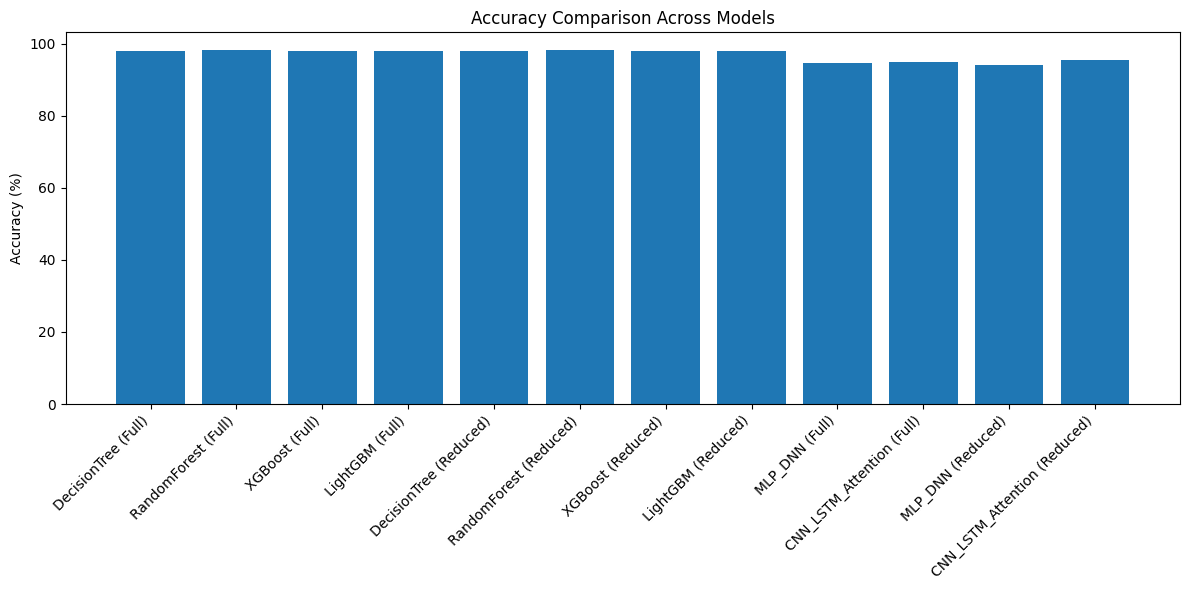

Saved: /kaggle/working/datasense_cic_iiot_2025/paper_outputs/Fig_Accuracy_Comparison.png


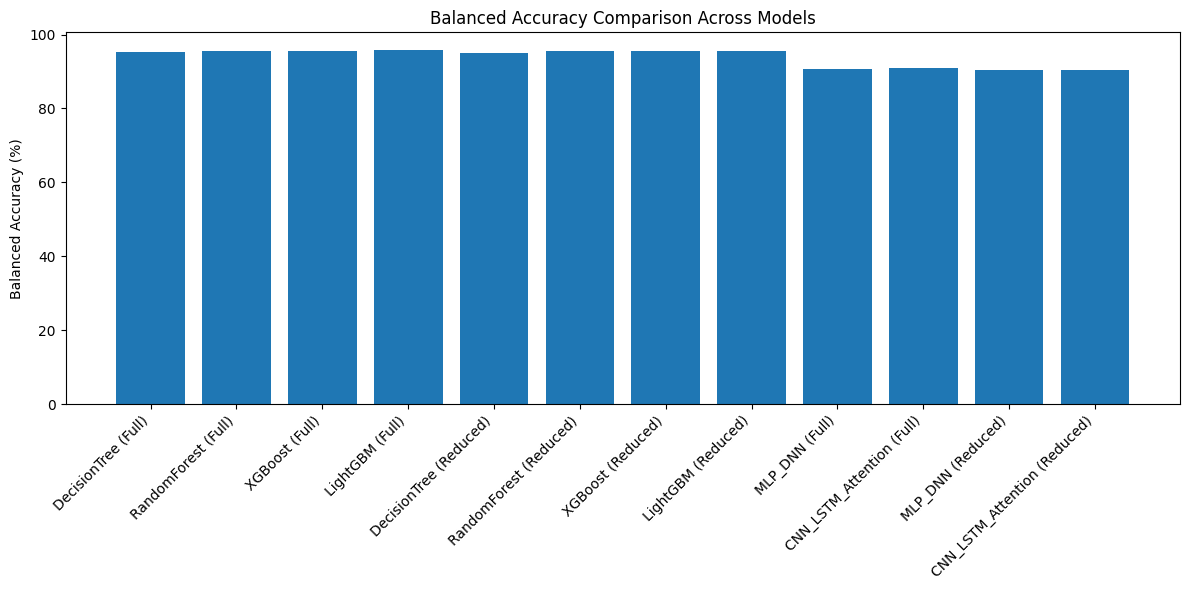

Saved: /kaggle/working/datasense_cic_iiot_2025/paper_outputs/Fig_Balanced_Accuracy_Comparison.png


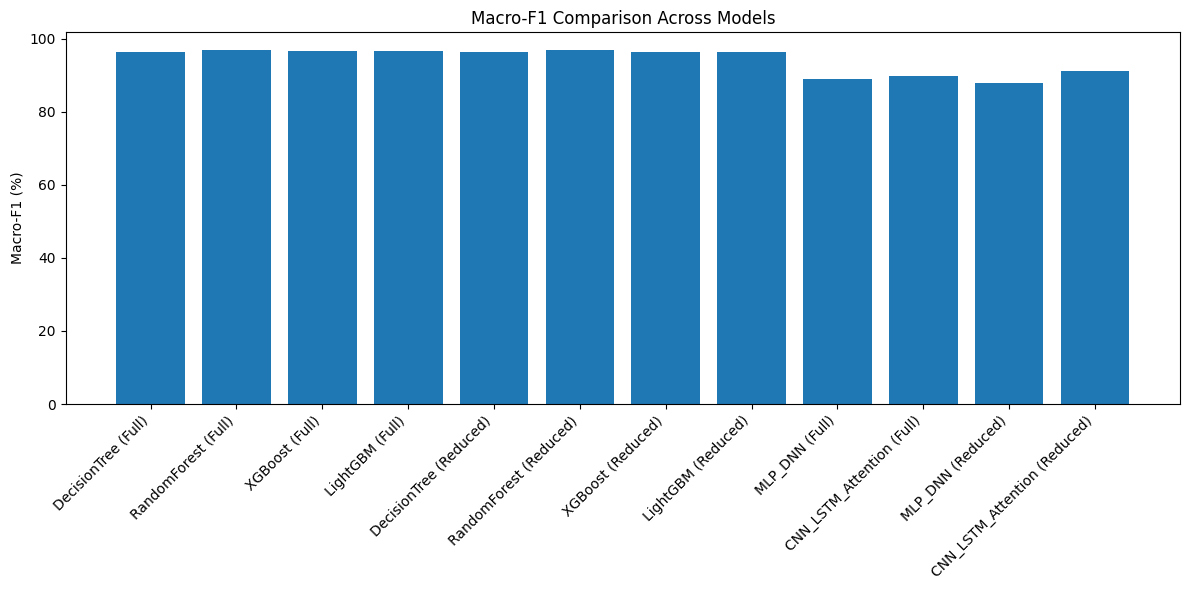

Saved: /kaggle/working/datasense_cic_iiot_2025/paper_outputs/Fig_MacroF1_Comparison.png


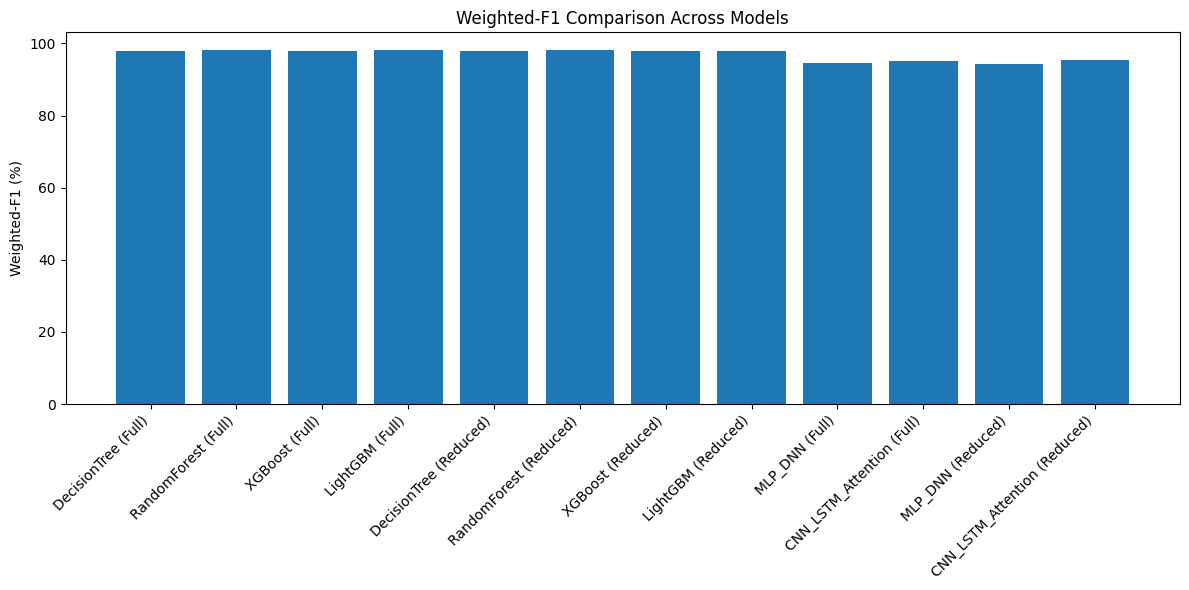

Saved: /kaggle/working/datasense_cic_iiot_2025/paper_outputs/Fig_WeightedF1_Comparison.png


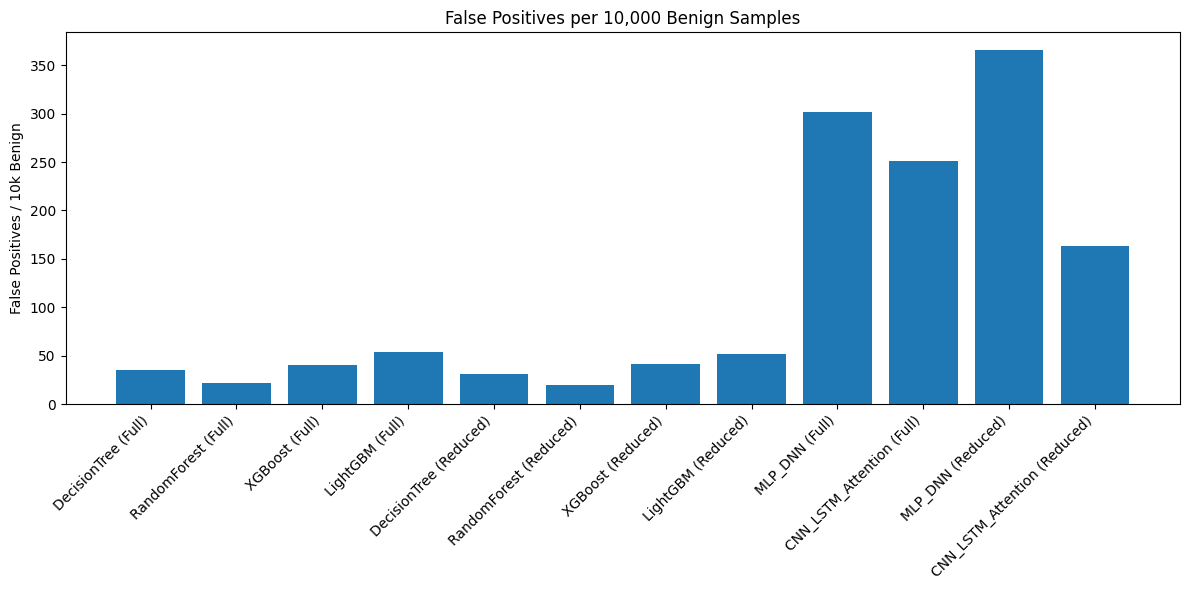

Saved: /kaggle/working/datasense_cic_iiot_2025/paper_outputs/Fig_FP_per_10000_Benign.png


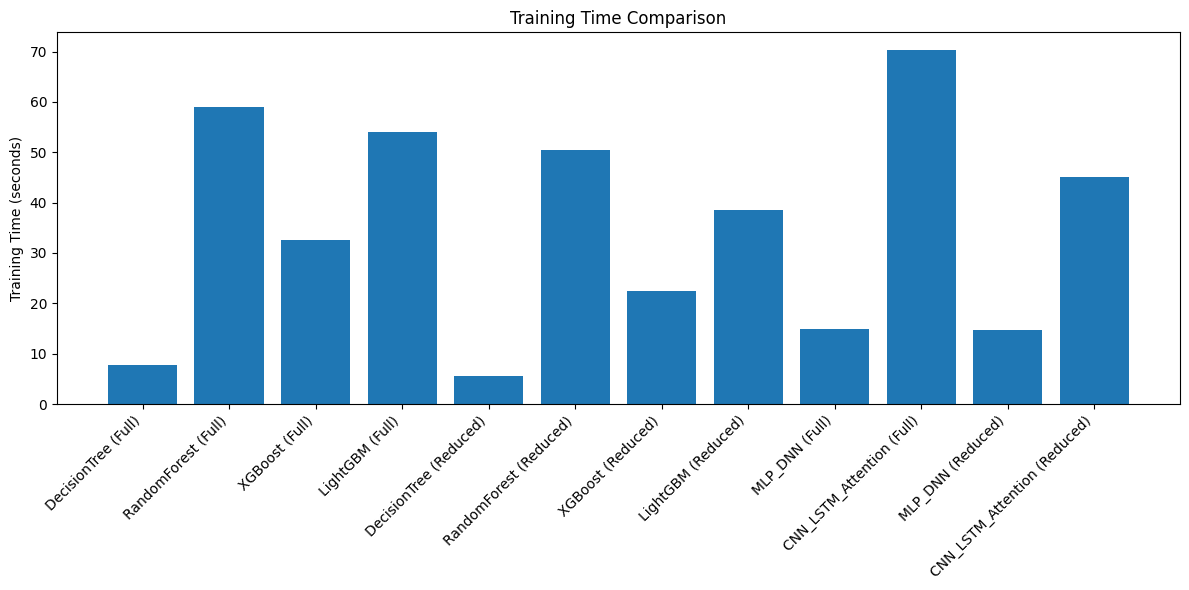

Saved: /kaggle/working/datasense_cic_iiot_2025/paper_outputs/Fig_Training_Time.png


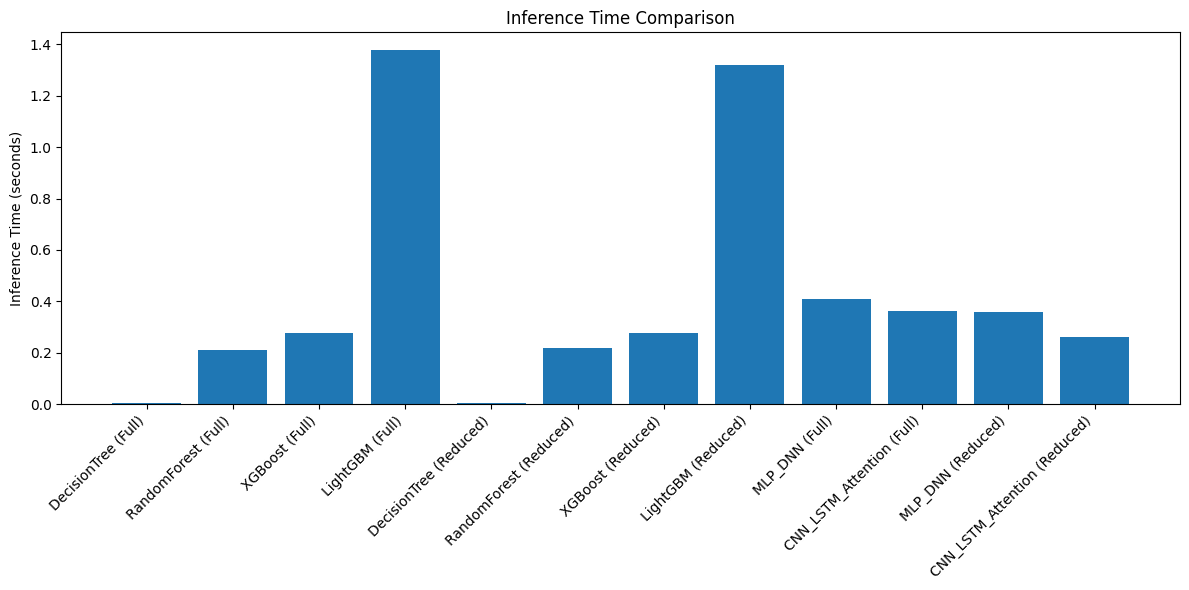

Saved: /kaggle/working/datasense_cic_iiot_2025/paper_outputs/Fig_Inference_Time.png


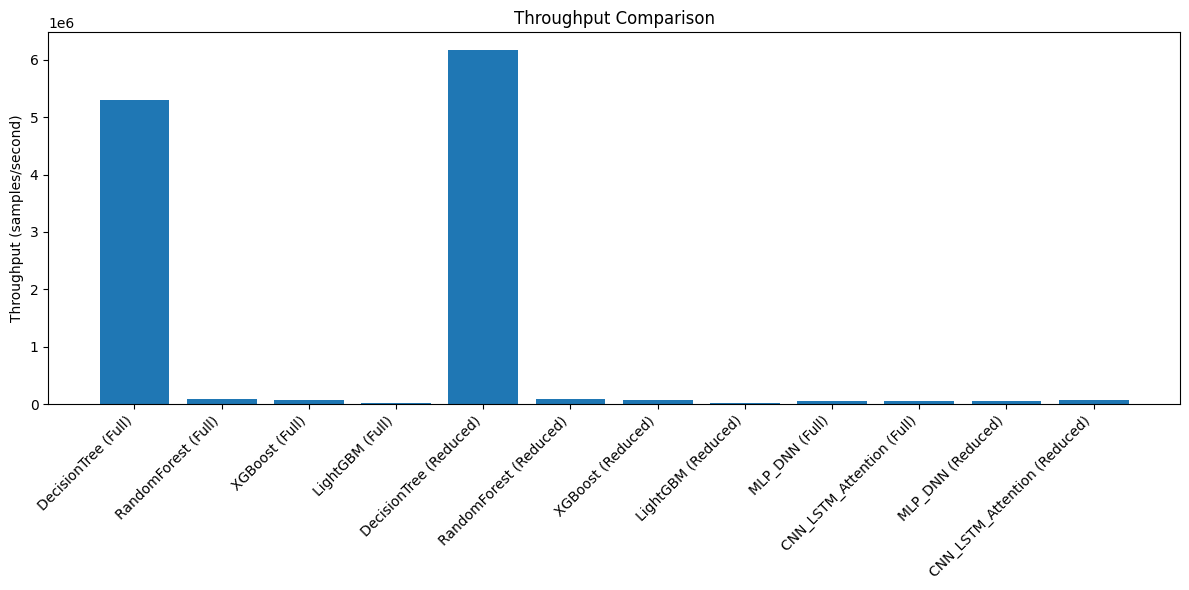

Saved: /kaggle/working/datasense_cic_iiot_2025/paper_outputs/Fig_Throughput.png


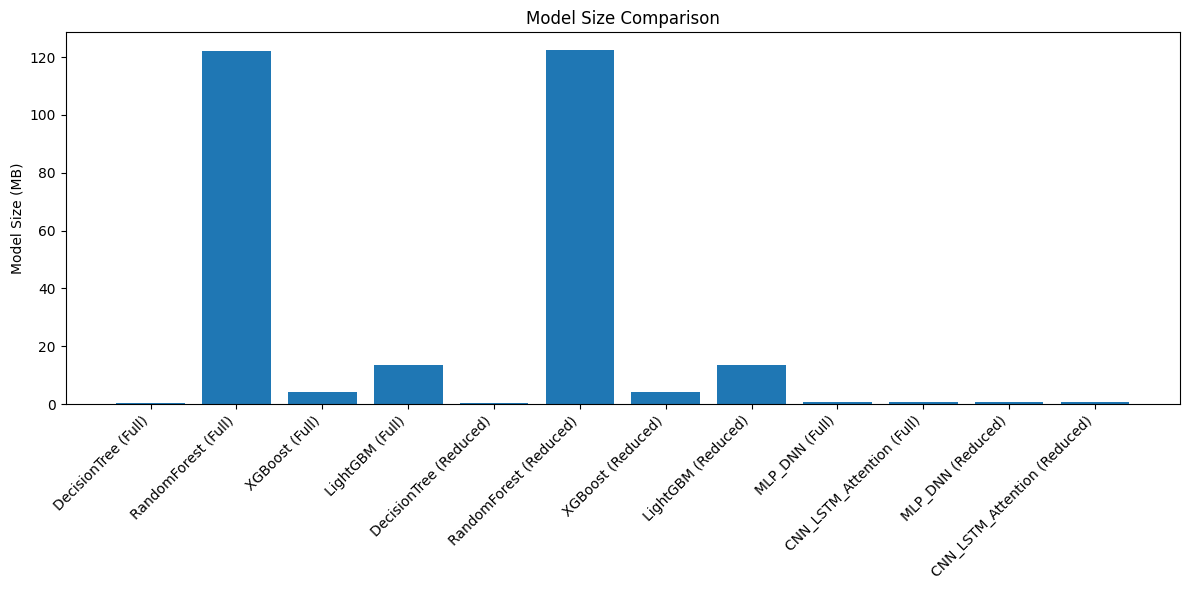

Saved: /kaggle/working/datasense_cic_iiot_2025/paper_outputs/Fig_Model_Size.png


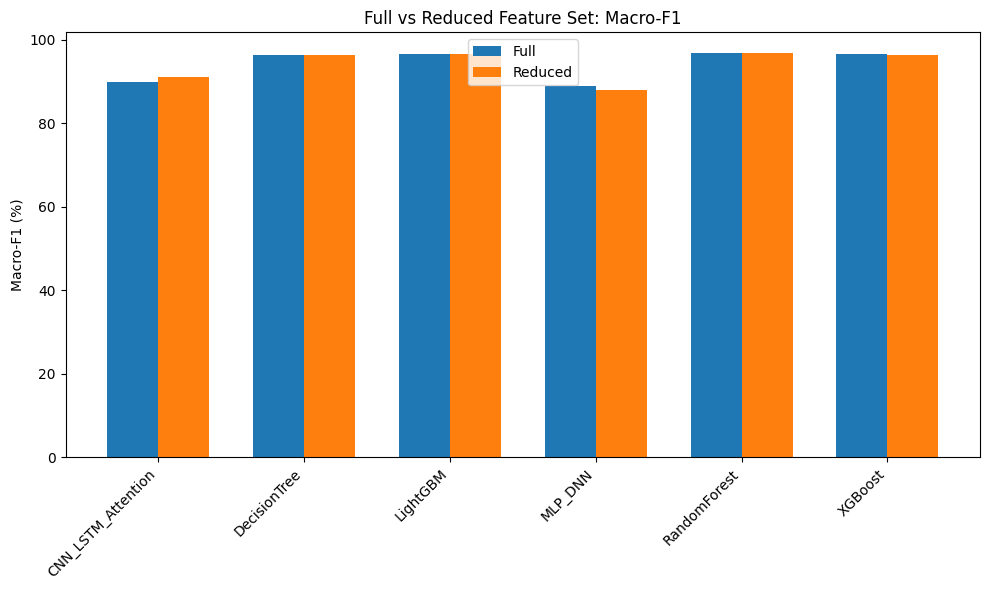

Saved: /kaggle/working/datasense_cic_iiot_2025/paper_outputs/Fig_Full_vs_Reduced_MacroF1.png
Created zip: /kaggle/working/datasense_cic_iiot_2025_paper_outputs.zip


/kaggle/working/datasense_cic_iiot_2025_paper_outputs.zip

In [26]:
# =========================
# PAPER-READY PLOTS AND ZIP
# =========================

final_df = pd.read_csv(RESULTS_DIR / "final_model_comparison.csv")
plot_df = final_df.copy()
plot_df["Model_Features"] = plot_df["model"].astype(str) + " (" + plot_df["feature_set"].astype(str) + ")"

def save_bar_plot(data, x_col, y_col, title, ylabel, filename, rotation=45):
    if y_col not in data.columns:
        print(f"Skipping {filename}; missing column {y_col}")
        return

    plt.figure(figsize=(12, 6))
    plt.bar(data[x_col].astype(str), data[y_col])
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    path = PAPER_DIR / filename
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

plot_df["accuracy_pct"] = plot_df["accuracy"] * 100
plot_df["balanced_accuracy_pct"] = plot_df["balanced_accuracy"] * 100
plot_df["macro_f1_pct"] = plot_df["macro_f1"] * 100
plot_df["weighted_f1_pct"] = plot_df["weighted_f1"] * 100

save_bar_plot(plot_df, "Model_Features", "accuracy_pct",
              "Accuracy Comparison Across Models", "Accuracy (%)",
              "Fig_Accuracy_Comparison.png")

save_bar_plot(plot_df, "Model_Features", "balanced_accuracy_pct",
              "Balanced Accuracy Comparison Across Models", "Balanced Accuracy (%)",
              "Fig_Balanced_Accuracy_Comparison.png")

save_bar_plot(plot_df, "Model_Features", "macro_f1_pct",
              "Macro-F1 Comparison Across Models", "Macro-F1 (%)",
              "Fig_MacroF1_Comparison.png")

save_bar_plot(plot_df, "Model_Features", "weighted_f1_pct",
              "Weighted-F1 Comparison Across Models", "Weighted-F1 (%)",
              "Fig_WeightedF1_Comparison.png")

save_bar_plot(plot_df, "Model_Features", "fp_per_10000_benign",
              "False Positives per 10,000 Benign Samples",
              "False Positives / 10k Benign",
              "Fig_FP_per_10000_Benign.png")

save_bar_plot(plot_df, "Model_Features", "training_time_sec",
              "Training Time Comparison", "Training Time (seconds)",
              "Fig_Training_Time.png")

save_bar_plot(plot_df, "Model_Features", "total_inference_time_sec",
              "Inference Time Comparison", "Inference Time (seconds)",
              "Fig_Inference_Time.png")

save_bar_plot(plot_df, "Model_Features", "throughput_samples_per_sec",
              "Throughput Comparison", "Throughput (samples/second)",
              "Fig_Throughput.png")

save_bar_plot(plot_df, "Model_Features", "model_size_mb",
              "Model Size Comparison", "Model Size (MB)",
              "Fig_Model_Size.png")

# Full vs Reduced Macro-F1 plot
pivot_macro = plot_df.pivot_table(
    index="model",
    columns="feature_set",
    values="macro_f1_pct",
    aggfunc="mean"
).reset_index()

if "Full" in pivot_macro.columns and "Reduced" in pivot_macro.columns:
    x = np.arange(len(pivot_macro["model"]))
    width = 0.35

    plt.figure(figsize=(10, 6))
    plt.bar(x - width / 2, pivot_macro["Full"], width, label="Full")
    plt.bar(x + width / 2, pivot_macro["Reduced"], width, label="Reduced")
    plt.title("Full vs Reduced Feature Set: Macro-F1")
    plt.ylabel("Macro-F1 (%)")
    plt.xticks(x, pivot_macro["model"], rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    path = PAPER_DIR / "Fig_Full_vs_Reduced_MacroF1.png"
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

# Save experiment metadata
metadata = {
    "dataset_name": DATASET_NAME,
    "dataset_path": dataset_path,
    "rows_after_cleaning": int(len(df)),
    "full_feature_count": int(len(feature_cols)),
    "reduced_feature_count": int(len(selected_features)),
    "class_names": class_names,
    "test_size": TEST_SIZE,
    "random_seed": RANDOM_SEED,
    "dl_epochs": DL_EPOCHS,
    "dl_patience": DL_PATIENCE,
    "top_k_features": TOP_K_FEATURES,
    "correlation_threshold": CORR_THRESHOLD,
    "dropped_labels": DROP_LABELS,
}
with open(PAPER_DIR / "experiment_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

# Copy key CSV/JSON artifacts into paper folder
for src in [
    ARTIFACTS_DIR / "used_numeric_features.csv",
    ARTIFACTS_DIR / "dropped_columns_report.csv",
    ARTIFACTS_DIR / "feature_importance_random_forest.csv",
    ARTIFACTS_DIR / "full_feature_names.json",
    ARTIFACTS_DIR / "reduced_feature_names.json",
    RESULTS_DIR / "final_model_comparison.csv",
]:
    if src.exists():
        dst = PAPER_DIR / src.name
        if src.resolve() != dst.resolve():
            import shutil
            shutil.copy(src, dst)

zip_path = Path("/kaggle/working/datasense_cic_iiot_2025_paper_outputs.zip")
if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for file in PAPER_DIR.rglob("*"):
        if file.is_file():
            zf.write(file, arcname=file.relative_to(PAPER_DIR))

print("Created zip:", zip_path)
FileLink(str(zip_path))
